## **CIFAR 10 Dataset**

### **Import Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

### **Load the Dataset Cifar10**

In [2]:
(X_train, y_train),(X_test, y_test) = cifar10.load_data()

### **Data Inspection**

In [3]:
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)
print("Unique Classes:", np.unique(y_train))

Train Shape: (50000, 32, 32, 3)
Test Shape: (10000, 32, 32, 3)
Unique Classes: [0 1 2 3 4 5 6 7 8 9]


### **Data Cleaning**

In [4]:
# Scale pixel values from 0-255 to 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

### **Label Encoding**

In [5]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

### **Visualize sample Images**

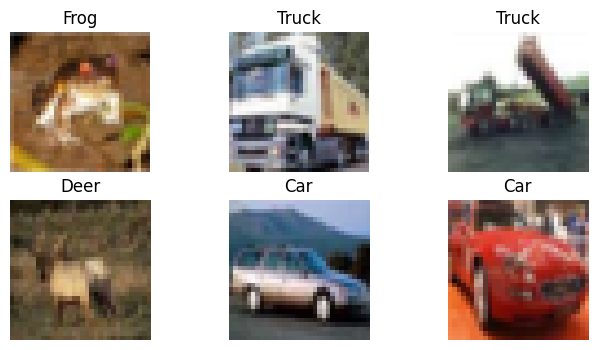

In [6]:
class_names = ['Airplane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
plt.figure(figsize = (8,4))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')
plt.show()

### **Build CNN Model**

In [7]:
model = Sequential()

# Convolutional Block 1
model.add(Conv2D(32, (3,3), activation = 'relu', input_shape = (32,32,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Convolutional Block 2
model.add(Conv2D(64, (3,3), activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Convolutional Block 3
model.add(Conv2D(128, (3,3), activation = 'relu'))
model.add(MaxPooling2D((2,2)))

C:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### **Flatten and Dense Layers**

In [8]:
model.add(Flatten())
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.4))
model.add(Dense(10, activation = 'softmax'))

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 30, 30, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 13, 13, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 160,586 (627.29 KB)

 Trainable params: 160,394 (626.54 KB)

 Non-trainable params: 192 (768.00 B)

### **Compile Model**

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


### **Train Model**

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.4376 - loss: 1.5586 - val_accuracy: 0.5466 - val_loss: 1.3035
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.5817 - loss: 1.1895 - val_accuracy: 0.5586 - val_loss: 1.2617
Epoch 3/10
534/625 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.6347 - loss: 1.0299 

### **Plot Accuracy Curve**

In [ ]:
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### **Model Evaluation**

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

### **Single Image Prediction**

In [ ]:
sample = X_test[5].reshape(1,32,32,3)
prediction = model.predict(sample)
print("Predicted Class:", class_names[np.argmax(prediction)])

### **Display Prediction**

In [ ]:
plt.imshow(X_test[5])
plt.title("Predicted: " + class_names[np.argmax(prediction)])
plt.axis('off')